In [55]:
"""
Electrospray Scaling Law Analyzer
---------------------------------

Uses:
- database.py module
- ElectrosprayDatabase class

Computes:
    d0, Q0, I0

Then:
- searches database for matching voltage
- computes mean current and flow rate
- plots:
        I/I0 vs Q/Q0
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add project root to Python path
sys.path.insert(0, str(r"C:\Users\HV\Desktop\bruno_work\main"))

from mapping.software.database import ElectrosprayDatabase


# ============================================================
# CONSTANTS
# ============================================================

EPSILON_0 = 8.854e-12  # vacuum permittivity


# ============================================================
# LIQUID PROPERTIES
# ============================================================

LIQUID = {
    "name": "Pure DMF",

    # SI units
    "surface_tension": 0.0364,      # N/m
    "density": 944.0,               # kg/m^3
    "conductivity": 1.5e-4,         # S/m
    "dielectric_constant": 36.7
}


# ============================================================
# USER SETTINGS
# ============================================================

DATABASE_FOLDER = "test"

TARGET_VOLTAGE = 5300       # volts
VOLTAGE_TOLERANCE = 100     # volts




In [56]:
# ============================================================
# SCALING LAWS
# ============================================================

def characteristic_diameter(sigma, rho, k):
    return ((sigma * EPSILON_0**2) / (rho * k**2))**(1/3)


def characteristic_flow_rate(sigma, rho, k):
    return (sigma * EPSILON_0) / (rho * k)


def characteristic_current(sigma, rho):
    return sigma * np.sqrt(EPSILON_0 / rho)


In [57]:
# ============================================================
# DATABASE SEARCH
# ============================================================

def get_matching_measurements():

    df = pd.read_csv("dmf.csv")

    #
    # Filter by:
    #   solution name
    #   target voltage
    #


    return df




In [58]:
# ============================================================
# MAIN
# ============================================================

    # --------------------------------------------------------
    # Load database
    # --------------------------------------------------------


# --------------------------------------------------------
# Compute characteristic scales
# --------------------------------------------------------

sigma = LIQUID["surface_tension"]
rho = LIQUID["density"]
k = LIQUID["conductivity"]

d0 = characteristic_diameter(sigma, rho, k)
Q0 = characteristic_flow_rate(sigma, rho, k)
I0 = characteristic_current(sigma, rho)

print("\n===================================")
print("Characteristic Scales")
print("===================================")

print(f"d0 = {d0:.3e} m")
print(f"Q0 = {Q0:.3e} m^3/s")
print(f"I0 = {I0:.3e} A")

# --------------------------------------------------------
# Get matching measurements
# --------------------------------------------------------
df= get_matching_measurements()




Characteristic Scales
d0 = 5.122e-07 m
Q0 = 2.276e-12 m^3/s
I0 = 3.525e-09 A


In [59]:
df

,flow_rate,current
0,6,78.394143
1,6,32.598322
2,6,31.928527
3,6,32.426216
4,6,27.935352
...,...,...
175,24,-163.898405
176,24,-185.828457
177,24,-174.638908
178,24,-201.501803



Loaded 180 matching measurements
After filtering negative current: 148 measurements
After aggregating by flow_rate: 18 unique flow rates

Experimental Means
Mean Flow Rate = 2.519e-10 m^3/s
Mean Current   = 7.831e-08 A


C:\Users\HV\AppData\Local\Temp\ipykernel_13824\2367271624.py:96: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 1000)
C:\Users\HV\AppData\Local\Temp\ipykernel_13824\2367271624.py:97: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1000)


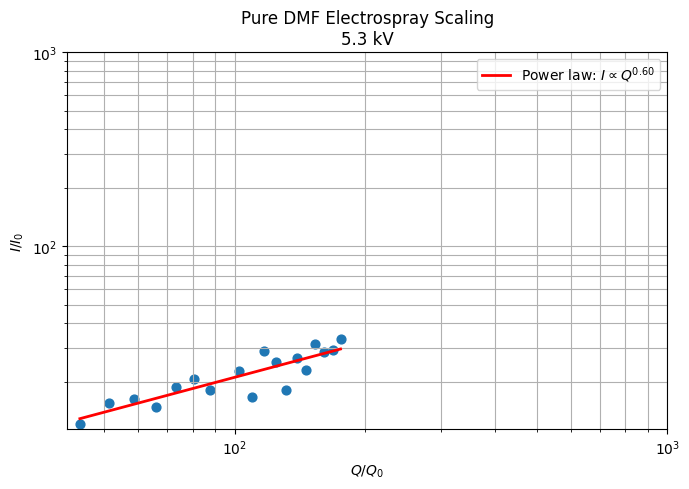

In [63]:
print(f"\nLoaded {len(df)} matching measurements")

    # --------------------------------------------------------
    # Filter out negative current values
    # --------------------------------------------------------

df_filtered = df[df["current"] > 0].copy()
print(f"After filtering negative current: {len(df_filtered)} measurements")

    # --------------------------------------------------------
    # Aggregate by flow_rate (use mean for duplicate flow rates)
    # --------------------------------------------------------

df_agg = df_filtered.groupby("flow_rate", as_index=False).agg({
    "current": "mean"
})
print(f"After aggregating by flow_rate: {len(df_agg)} unique flow rates")

    # --------------------------------------------------------
    # Convert units
    # --------------------------------------------------------

    #
    # flow_rate assumed:
    #   uL/min
    #
    # convert to m^3/s
    #

flow_rate_m3s = (
    df_agg["flow_rate"].values
    * 1e-9
    / 60.0
)

    #
    # current assumed:
    #   nA
    #
    # convert to A
    #

current_A = (
    df_agg["current"].values
    * 1e-9
)

    # --------------------------------------------------------
    # Dimensionless quantities
    # --------------------------------------------------------

Q_star = flow_rate_m3s / Q0
I_star = current_A / I0

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

mean_flow = np.mean(flow_rate_m3s)
mean_current = np.mean(current_A)

print("\n===================================")
print("Experimental Means")
print("===================================")
print(f"Mean Flow Rate = {mean_flow:.3e} m^3/s")
print(f"Mean Current   = {mean_current:.3e} A")

    # --------------------------------------------------------
    # Plot scaling law
    # --------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(
    Q_star,
    I_star,
    s=40
)
# After your scatter plot, add this:
z = np.polyfit(np.log(Q_star), np.log(I_star), 1)  # Linear fit in log space
a = np.exp(z[1])
b = z[0]

# Create line points
Q_star_line = np.logspace(np.log10(Q_star.min()), np.log10(Q_star.max()), 100)
I_star_fit = a * Q_star_line**b

# Plot on log-log scale
plt.loglog(Q_star_line, I_star_fit, "r-", linewidth=2, 
           label=f"Power law: $I \\propto Q^{{{b:.2f}}}$")
plt.legend()

plt.xlabel(r"$Q/Q_0$")
plt.ylabel(r"$I/I_0$")
plt.xscale("log")
plt.yscale("log")
plt.xlim(0, 1000)
plt.ylim(0, 1000)
plt.title(
    f"{LIQUID['name']} Electrospray Scaling\n"
    f"{TARGET_VOLTAGE/1000:.1f} kV"
)
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


Loaded 180 matching measurements
After filtering negative current: 148 measurements
After aggregating by flow_rate: 18 unique flow rates

Experimental Means
Mean Flow Rate = 2.519e-10 m^3/s
Mean Current   = 7.831e-08 A


C:\Users\HV\AppData\Local\Temp\ipykernel_13824\2122022246.py:96: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 40)


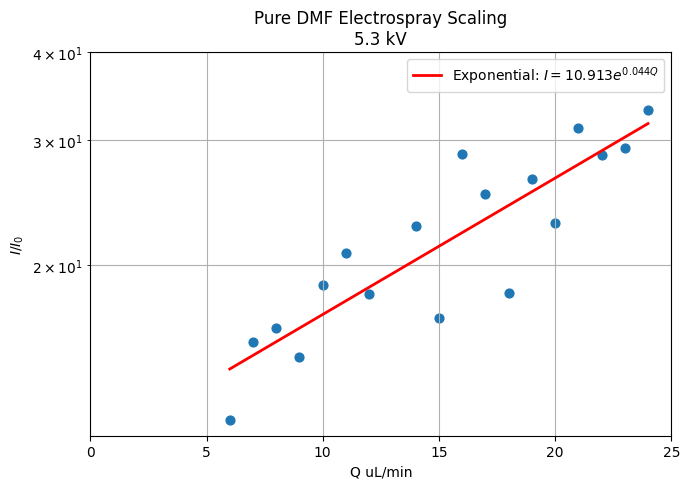

In [64]:
print(f"\nLoaded {len(df)} matching measurements")

    # --------------------------------------------------------
    # Filter out negative current values
    # --------------------------------------------------------

df_filtered = df[df["current"] > 0].copy()
print(f"After filtering negative current: {len(df_filtered)} measurements")

    # --------------------------------------------------------
    # Aggregate by flow_rate (use mean for duplicate flow rates)
    # --------------------------------------------------------

df_agg = df_filtered.groupby("flow_rate", as_index=False).agg({
    "current": "mean"
})
print(f"After aggregating by flow_rate: {len(df_agg)} unique flow rates")

    # --------------------------------------------------------
    # Convert units
    # --------------------------------------------------------

    #
    # flow_rate assumed:
    #   uL/min
    #
    # convert to m^3/s
    #

flow_rate_m3s = (
    df_agg["flow_rate"].values
    * 1e-9
    / 60.0
)

    #
    # current assumed:
    #   nA
    #
    # convert to A
    #

current_A = (
    df_agg["current"].values
    * 1e-9
)

    # --------------------------------------------------------
    # Dimensionless quantities
    # --------------------------------------------------------

Q_star = flow_rate_m3s / 1e-9 * 60.0
I_star = current_A / I0

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

mean_flow = np.mean(flow_rate_m3s)
mean_current = np.mean(current_A)

print("\n===================================")
print("Experimental Means")
print("===================================")
print(f"Mean Flow Rate = {mean_flow:.3e} m^3/s")
print(f"Mean Current   = {mean_current:.3e} A")

    # --------------------------------------------------------
    # Plot scaling law
    # --------------------------------------------------------

plt.figure(figsize=(7, 5))
plt.scatter(
    Q_star,
    I_star,
    s=40
)
# After your scatter plot, add this:
z = np.polyfit(Q_star, np.log(I_star), 1)  # Linear fit in log(y) vs x
a = np.exp(z[1])
b = z[0]

# Create line points
Q_star_line = np.linspace(Q_star.min(), Q_star.max(), 100)
I_star_fit = a * np.exp(b * Q_star_line)

# Plot on semi-log scale
plt.semilogy(Q_star_line, I_star_fit, "r-", linewidth=2, 
             label=f"Exponential: $I = {a:.3f} e^{{{b:.3f}Q}}$")
plt.legend()

plt.xlabel(r"Q uL/min")
plt.ylabel(r"$I/I_0$")
plt.yscale("log")
plt.xlim(0, 25)
plt.ylim(0, 40)
plt.title(
    f"{LIQUID['name']} Electrospray Scaling\n"
    f"{TARGET_VOLTAGE/1000:.1f} kV"
)
plt.grid(True, which="both")
plt.tight_layout()
plt.show()